# Notebook 05 - Vận hành và chất lượng

**Mục tiêu:** phân tích vận chuyển, trả hàng, đánh giá và tồn kho để tìm nút thắt vận hành ảnh hưởng đến doanh thu, trải nghiệm khách hàng và khả năng đáp ứng nhu cầu.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
for candidate in (PROJECT_ROOT, *PROJECT_ROOT.parents):
    if (candidate / "datathon-2026-round-1").exists():
        PROJECT_ROOT = candidate
        break
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Markdown, display

from EDA.constants.config import FIGURES_DIR, WEEKDAY_ORDER, AGE_ORDER, SIZE_ORDER
from EDA.utils.io import load_tables, build_order_metrics, build_order_item_metrics
from EDA.utils.plotting import setup_vietnamese_style, save_figure, format_money_axis, format_percent_axis, money_formatter
from EDA.utils.validation import quality_report, foreign_key_report

setup_vietnamese_style()
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

## 1. Tải dữ liệu và chuẩn bị bảng vận hành

In [2]:
tables = load_tables(["shipments", "orders", "returns", "reviews", "inventory", "products", "order_items", "geography"])
shipments, orders, returns, reviews = tables["shipments"], tables["orders"], tables["returns"], tables["reviews"]
inventory, products, items, geography = tables["inventory"], tables["products"], tables["order_items"], tables["geography"]
display(quality_report(tables))
geo = geography.rename(columns={"zip": "ship_zip", "city": "ship_city"})
ship = shipments.merge(orders[["order_id", "order_date", "order_status", "zip"]], on="order_id", how="left").merge(geo, left_on="zip", right_on="ship_zip", how="left")
ship["ship_lag_days"] = (ship.ship_date - ship.order_date).dt.days
ship["delivery_lag_days"] = (ship.delivery_date - ship.ship_date).dt.days
ship["total_delivery_days"] = (ship.delivery_date - ship.order_date).dt.days
display(Markdown(f"**Insight ngắn:** có {shipments.order_id.nunique():,} đơn có thông tin giao vận. Metric giao hàng được tính từ ngày đặt, ngày gửi và ngày giao."))

,bảng,số dòng,số cột,ô thiếu,dòng trùng,dung lượng MB
7,geography,39948,4,0,0,7.7800
4,inventory,60247,17,0,0,18.1400
6,order_items,714669,7,1152816,0,80.1100
1,orders,646945,8,0,0,182.5200
5,products,2412,8,0,0,0.8000
2,returns,39939,7,0,0,6.6800
3,reviews,113551,7,0,0,19.4900
0,shipments,566067,4,0,0,17.2800


**Insight ngắn:** có 566,067 đơn có thông tin giao vận. Metric giao hàng được tính từ ngày đặt, ngày gửi và ngày giao.

## 2. Tốc độ giao hàng và khác biệt theo vùng

C:\Users\ACER\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


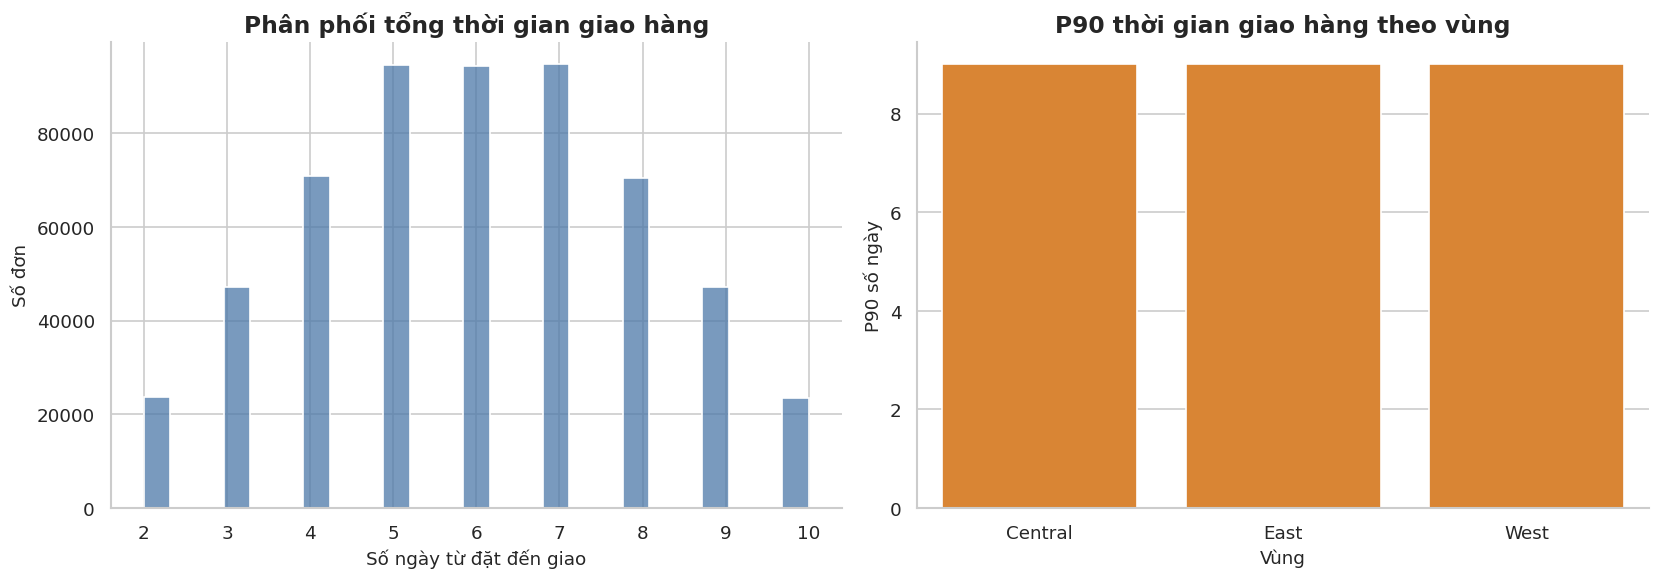

,region,shipments,median_total_days,p90_total_days,free_shipping_rate,avg_shipping_fee
0,Central,161388,6.0,9.0,0.15%,4.79
1,East,257756,6.0,9.0,0.15%,4.83
2,West,146923,6.0,9.0,0.13%,5.39


**Insight ngắn:** trung vị giao hàng toàn bộ là 6.0 ngày; vùng `Central` có P90 giao hàng cao nhất, phản ánh nhóm khách chịu trải nghiệm chậm nhất.

In [3]:
delivery_region = ship.groupby("region", as_index=False).agg(shipments=("order_id", "nunique"), median_total_days=("total_delivery_days", "median"), p90_total_days=("total_delivery_days", lambda x: x.quantile(.9)), free_shipping_rate=("shipping_fee", lambda x: (x == 0).mean()), avg_shipping_fee=("shipping_fee", "mean")).sort_values("p90_total_days", ascending=False)
median_delivery = ship.total_delivery_days.median()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(ship.total_delivery_days, bins=25, color="#4c78a8", ax=axes[0]); axes[0].set_title("Phân phối tổng thời gian giao hàng"); axes[0].set_xlabel("Số ngày từ đặt đến giao"); axes[0].set_ylabel("Số đơn")
sns.barplot(data=delivery_region, x="region", y="p90_total_days", color="#f58518", ax=axes[1]); axes[1].set_title("P90 thời gian giao hàng theo vùng"); axes[1].set_xlabel("Vùng"); axes[1].set_ylabel("P90 số ngày")
save_figure("05_operations_quality_delivery", fig); plt.show()
display(delivery_region.style.format({"median_total_days": "{:.1f}", "p90_total_days": "{:.1f}", "free_shipping_rate": "{:.2%}", "avg_shipping_fee": "{:.2f}"}))
slow_region = delivery_region.iloc[0].region
display(Markdown(f"**Insight ngắn:** trung vị giao hàng toàn bộ là {median_delivery:.1f} ngày; vùng `{slow_region}` có P90 giao hàng cao nhất, phản ánh nhóm khách chịu trải nghiệm chậm nhất."))

## 3. Trả hàng và đánh giá khách hàng

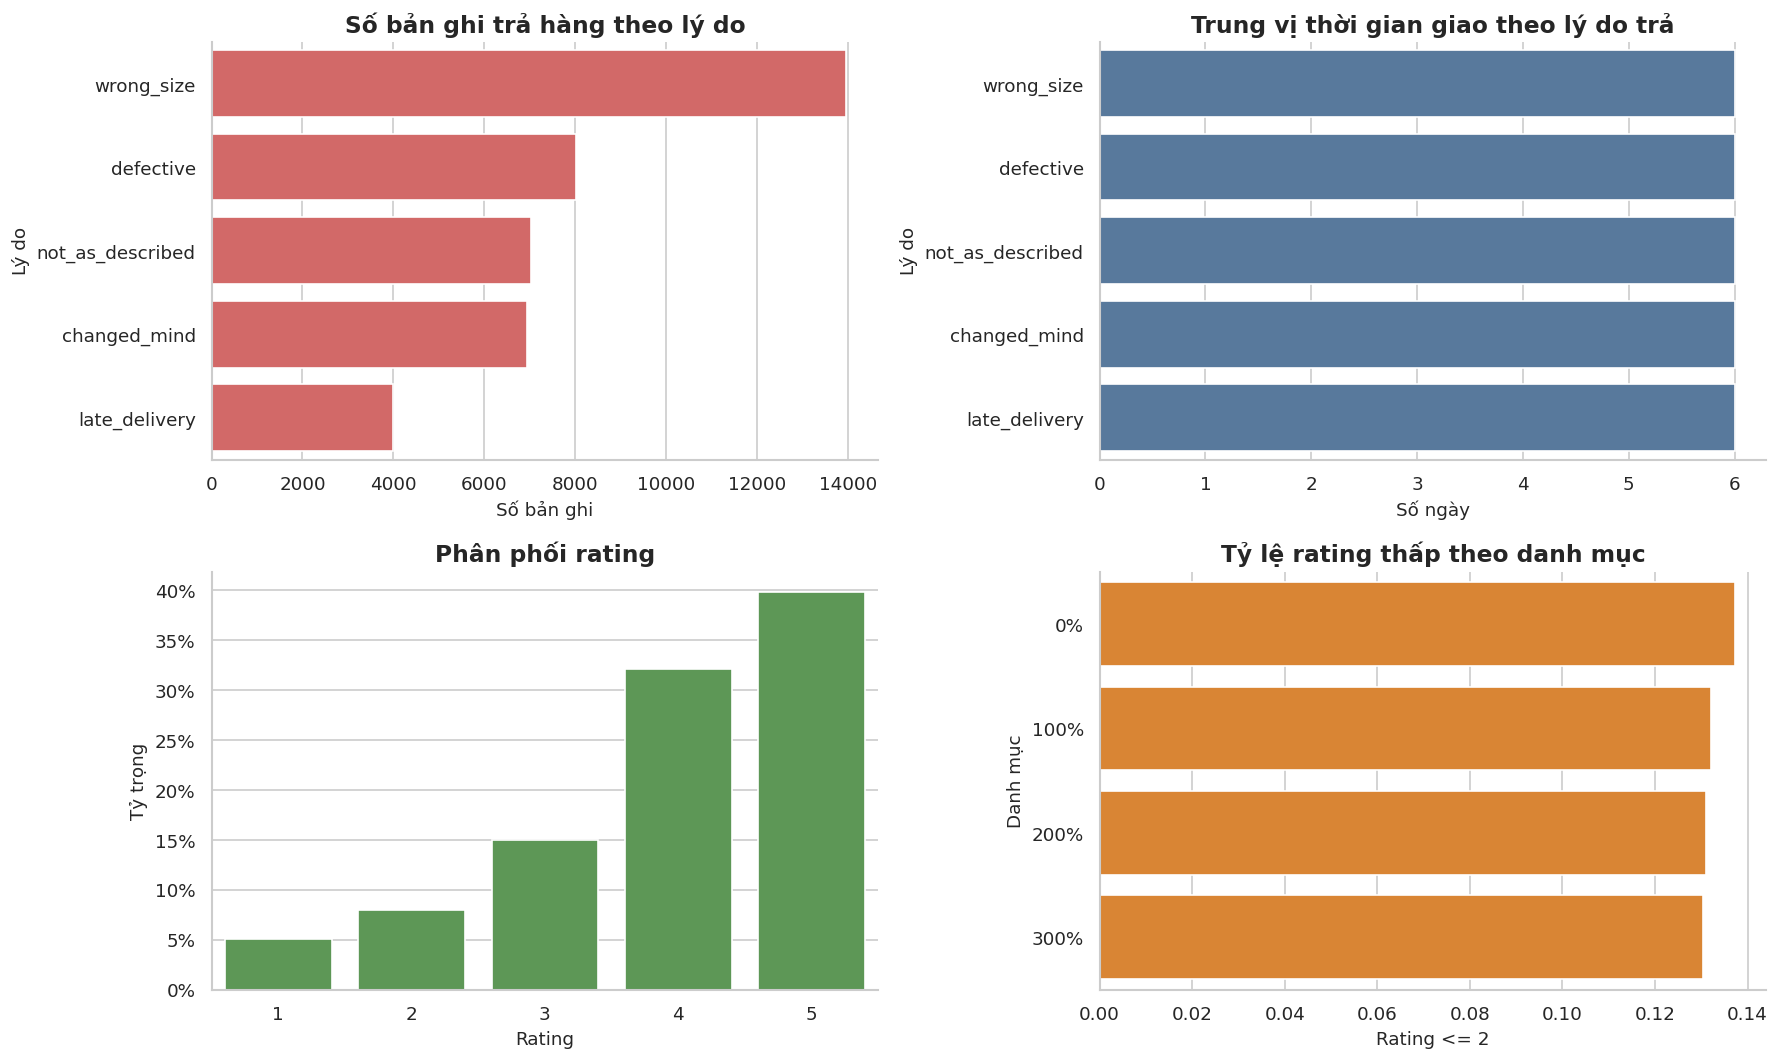

,return_reason,return_rows,return_qty,refund_amount,median_delivery_days
4,wrong_size,13967,38042,"176,687,201",6.0
1,defective,8020,22274,"103,599,143",6.0
3,not_as_described,7035,19358,"90,653,191",6.0
0,changed_mind,6931,19144,"89,721,759",6.0
2,late_delivery,3986,10768,"49,937,213",6.0


**Insight ngắn:** lý do trả hàng phổ biến nhất là `wrong_size`; danh mục `Casual` có tỷ lệ rating thấp cao nhất. Cần ưu tiên vấn đề có cả tần suất và chi phí hoàn tiền lớn.

In [4]:
ret_prod = returns.merge(products, on="product_id", how="left")
ret_ship = ret_prod.merge(ship[["order_id", "total_delivery_days", "region"]], on="order_id", how="left")
reason = ret_ship.groupby("return_reason", as_index=False).agg(return_rows=("return_id", "count"), return_qty=("return_quantity", "sum"), refund_amount=("refund_amount", "sum"), median_delivery_days=("total_delivery_days", "median")).sort_values("return_rows", ascending=False)
rev_prod = reviews.merge(products, on="product_id", how="left")
rating_dist = reviews.rating.value_counts(normalize=True).sort_index().rename_axis("rating").reset_index(name="share")
rating_cat = rev_prod.groupby("category", as_index=False).agg(avg_rating=("rating", "mean"), review_count=("review_id", "count"), low_rating_rate=("rating", lambda x: (x <= 2).mean())).sort_values("low_rating_rate", ascending=False)

fig, axes = plt.subplots(2, 2, figsize=(15, 9))
sns.barplot(data=reason, y="return_reason", x="return_rows", color="#e45756", ax=axes[0,0]); axes[0,0].set_title("Số bản ghi trả hàng theo lý do"); axes[0,0].set_xlabel("Số bản ghi"); axes[0,0].set_ylabel("Lý do")
sns.barplot(data=reason, y="return_reason", x="median_delivery_days", color="#4c78a8", ax=axes[0,1]); axes[0,1].set_title("Trung vị thời gian giao theo lý do trả"); axes[0,1].set_xlabel("Số ngày"); axes[0,1].set_ylabel("Lý do")
sns.barplot(data=rating_dist, x="rating", y="share", color="#54a24b", ax=axes[1,0]); axes[1,0].set_title("Phân phối rating"); axes[1,0].set_xlabel("Rating"); axes[1,0].set_ylabel("Tỷ trọng"); format_percent_axis(axes[1,0])
sns.barplot(data=rating_cat, y="category", x="low_rating_rate", color="#f58518", ax=axes[1,1]); axes[1,1].set_title("Tỷ lệ rating thấp theo danh mục"); axes[1,1].set_xlabel("Rating <= 2"); axes[1,1].set_ylabel("Danh mục"); format_percent_axis(axes[1,1])
save_figure("05_operations_quality_returns_reviews", fig); plt.show()
top_return_reason = reason.iloc[0].return_reason
low_rating_category = rating_cat.iloc[0].category
display(reason.style.format({"refund_amount": "{:,.0f}", "median_delivery_days": "{:.1f}"}))
display(Markdown(f"**Insight ngắn:** lý do trả hàng phổ biến nhất là `{top_return_reason}`; danh mục `{low_rating_category}` có tỷ lệ rating thấp cao nhất. Cần ưu tiên vấn đề có cả tần suất và chi phí hoàn tiền lớn."))

## 4. Tồn kho: stockout, overstock và khả năng đáp ứng

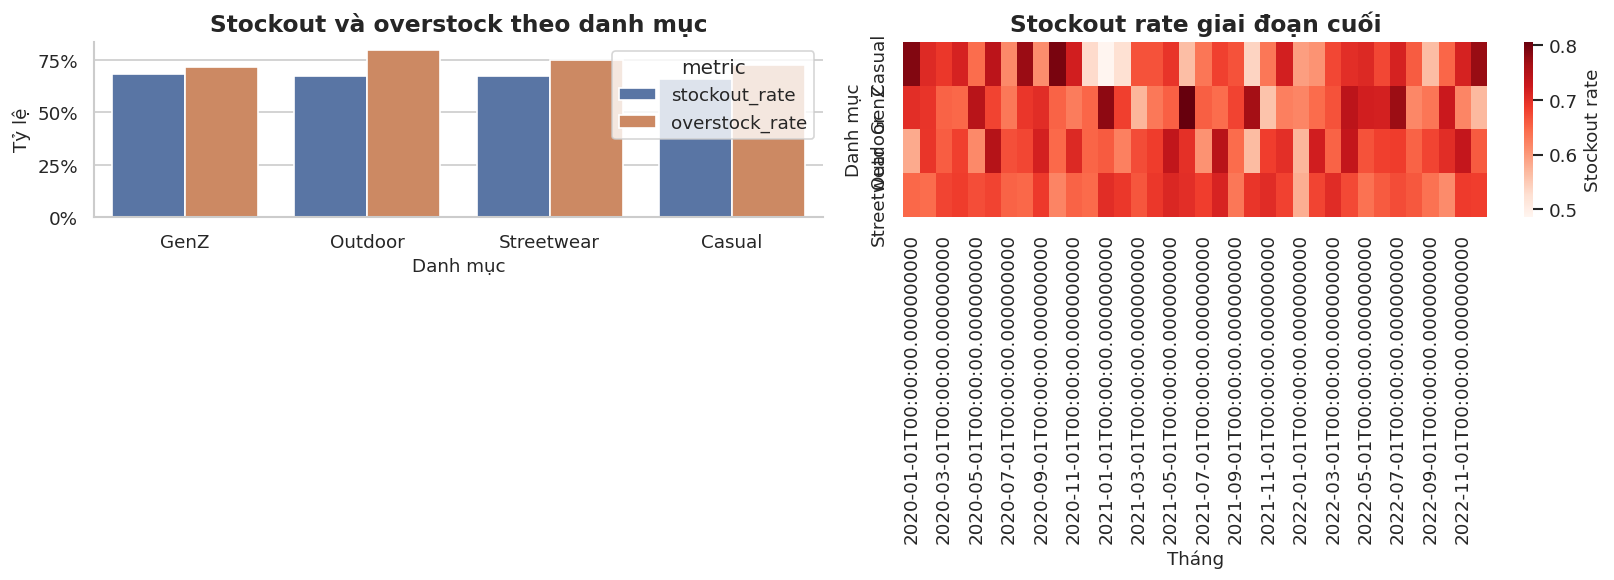

,category,stockout_rate,overstock_rate,avg_fill_rate,median_days_supply,avg_sell_through,stock_on_hand
1,GenZ,68.29%,71.63%,96.17%,210.0,16.80%,"584,757"
2,Outdoor,67.35%,79.85%,96.27%,300.0,13.51%,"4,749,891"
3,Streetwear,67.32%,74.93%,96.02%,219.0,15.98%,"5,759,494"
0,Casual,66.20%,72.59%,96.18%,195.0,16.84%,"310,522"


**Insight ngắn:** `GenZ` có stockout rate cao nhất, còn `Outdoor` có overstock rate cao nhất. Việc cùng tồn tại stockout và overstock gợi ý vấn đề phân bổ SKU hơn là chỉ thiếu tổng tồn kho.

In [5]:
inventory["snapshot_month"] = inventory.snapshot_date.dt.to_period("M").dt.to_timestamp()
inv_cat = inventory.groupby("category", as_index=False).agg(stockout_rate=("stockout_flag", "mean"), overstock_rate=("overstock_flag", "mean"), avg_fill_rate=("fill_rate", "mean"), median_days_supply=("days_of_supply", "median"), avg_sell_through=("sell_through_rate", "mean"), stock_on_hand=("stock_on_hand", "sum")).sort_values("stockout_rate", ascending=False)
inv_month = inventory.groupby(["snapshot_month", "category"], as_index=False).agg(stockout_rate=("stockout_flag", "mean"), overstock_rate=("overstock_flag", "mean")).tail(36 * inventory.category.nunique())
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
inv_plot = inv_cat.melt(id_vars="category", value_vars=["stockout_rate", "overstock_rate"], var_name="metric", value_name="rate")
sns.barplot(data=inv_plot, x="category", y="rate", hue="metric", ax=axes[0]); axes[0].set_title("Stockout và overstock theo danh mục"); axes[0].set_xlabel("Danh mục"); axes[0].set_ylabel("Tỷ lệ"); format_percent_axis(axes[0])
sns.heatmap(inv_month.pivot(index="snapshot_month", columns="category", values="stockout_rate").T, cmap="Reds", ax=axes[1], cbar_kws={"label": "Stockout rate"}); axes[1].set_title("Stockout rate giai đoạn cuối"); axes[1].set_xlabel("Tháng"); axes[1].set_ylabel("Danh mục")
save_figure("05_operations_quality_inventory", fig); plt.show()
high_stockout = inv_cat.iloc[0].category
high_overstock = inv_cat.sort_values("overstock_rate", ascending=False).iloc[0].category
display(inv_cat.style.format({"stockout_rate": "{:.2%}", "overstock_rate": "{:.2%}", "avg_fill_rate": "{:.2%}", "median_days_supply": "{:,.1f}", "avg_sell_through": "{:.2%}", "stock_on_hand": "{:,.0f}"}))
display(Markdown(f"**Insight ngắn:** `{high_stockout}` có stockout rate cao nhất, còn `{high_overstock}` có overstock rate cao nhất. Việc cùng tồn tại stockout và overstock gợi ý vấn đề phân bổ SKU hơn là chỉ thiếu tổng tồn kho."))

## 5. SKU rủi ro: kết hợp tồn kho, trả hàng và rating

C:\Users\ACER\AppData\Local\Temp\ipykernel_11100\4253042556.py:10: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sku["risk_score"] = sku.stockout_rate.fillna(0) + sku.return_rate.fillna(0) + sku.rating_penalty.fillna(0)


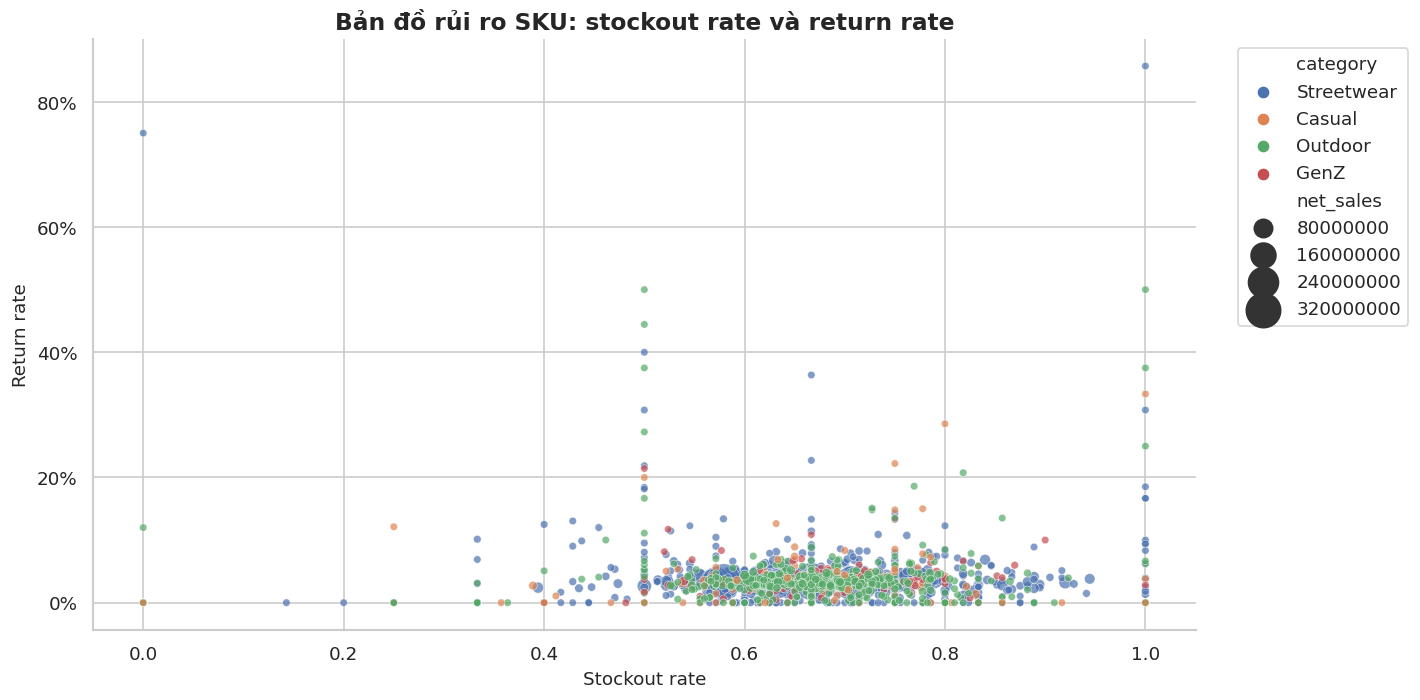

,product_id,product_name,category,segment,units_sold,net_sales,stockout_rate,return_rate,avg_rating,risk_score
632,2340,VietMotion UE-14,Streetwear,Performance,13.000000,"72,422",100.00%,30.77%,2.00,2.06
688,323,LotusWear UE-44,Streetwear,Performance,7.000000,"54,373",75.00%,14.29%,1.00,1.89
1106,234,LotusWear UR-06,Streetwear,Standard,7.000000,"36,676",100.00%,85.71%,nan,1.86
107,643,SaigonFlex UC-08,Streetwear,Everyday,9.000000,"110,291",100.00%,0.00%,2.00,1.75
520,1195,MekongFit UE-31,Streetwear,Performance,4.000000,"11,104",100.00%,0.00%,2.00,1.75
684,319,LotusWear UE-40,Streetwear,Performance,4.000000,"52,376",100.00%,0.00%,2.00,1.75
1995,393,SaigonFlex RP-02,Outdoor,Activewear,20.000000,"97,588",100.00%,0.00%,2.00,1.75
1968,52,DragonWear RP-07,Outdoor,Activewear,15.000000,"59,636",75.00%,0.00%,1.00,1.75
1518,198,DragonWear YY-02,GenZ,Trendy,71.000000,"380,308",100.00%,2.82%,2.33,1.69
1803,1298,VietMode MA-34,Casual,All-weather,80.000000,"355,497",77.78%,15.00%,2.00,1.68


**Kết luận chung:** trung vị giao hàng là 6.0 ngày, lý do trả hàng phổ biến nhất là `wrong_size`, và tồn kho có cả stockout/overstock. Danh sách SKU rủi ro là backlog hành động cho vận hành, mua hàng và đội sản phẩm.

In [6]:
item = build_order_item_metrics(items).merge(products, on="product_id", how="left")
sold = item.groupby("product_id", as_index=False).agg(units_sold=("quantity", "sum"), net_sales=("net_sales", "sum"))
ret = returns.groupby("product_id", as_index=False).agg(return_qty=("return_quantity", "sum"), refund_amount=("refund_amount", "sum"))
rev = reviews.groupby("product_id", as_index=False).agg(avg_rating=("rating", "mean"), review_count=("review_id", "count"))
inv = inventory.groupby("product_id", as_index=False).agg(stockout_rate=("stockout_flag", "mean"), overstock_rate=("overstock_flag", "mean"), avg_fill_rate=("fill_rate", "mean"))
sku = products[["product_id", "product_name", "category", "segment"]].merge(sold, on="product_id", how="left").merge(ret, on="product_id", how="left").merge(rev, on="product_id", how="left").merge(inv, on="product_id", how="left")
sku[["units_sold", "net_sales", "return_qty", "refund_amount"]] = sku[["units_sold", "net_sales", "return_qty", "refund_amount"]].fillna(0)
sku["return_rate"] = sku.return_qty / sku.units_sold.replace(0, pd.NA)
sku["rating_penalty"] = (5 - sku.avg_rating) / 4
sku["risk_score"] = sku.stockout_rate.fillna(0) + sku.return_rate.fillna(0) + sku.rating_penalty.fillna(0)
risky = sku[sku.units_sold > 0].sort_values("risk_score", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(12, 6))
sns.scatterplot(data=sku[sku.units_sold > 0], x="stockout_rate", y="return_rate", size="net_sales", hue="category", alpha=.7, sizes=(20, 500), ax=ax)
ax.set_title("Bản đồ rủi ro SKU: stockout rate và return rate"); ax.set_xlabel("Stockout rate"); ax.set_ylabel("Return rate"); format_percent_axis(ax); ax.legend(bbox_to_anchor=(1.03, 1), loc="upper left")
save_figure("05_operations_quality_sku_risk", fig); plt.show()
display(risky[["product_id", "product_name", "category", "segment", "units_sold", "net_sales", "stockout_rate", "return_rate", "avg_rating", "risk_score"]].style.format({"net_sales": "{:,.0f}", "stockout_rate": "{:.2%}", "return_rate": "{:.2%}", "avg_rating": "{:.2f}", "risk_score": "{:.2f}"}))
display(Markdown(f"**Kết luận chung:** trung vị giao hàng là {median_delivery:.1f} ngày, lý do trả hàng phổ biến nhất là `{top_return_reason}`, và tồn kho có cả stockout/overstock. Danh sách SKU rủi ro là backlog hành động cho vận hành, mua hàng và đội sản phẩm."))